In [41]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MultiLabelBinarizer
import seaborn as sns
import numpy as np
import glob
import os

sns.set_theme(style="whitegrid")

# Hospital A

Loading into memory...
Size of hospital A train set: 2380
Size of hospital A eval set: 310


/tmp/ipykernel_782938/4030580348.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


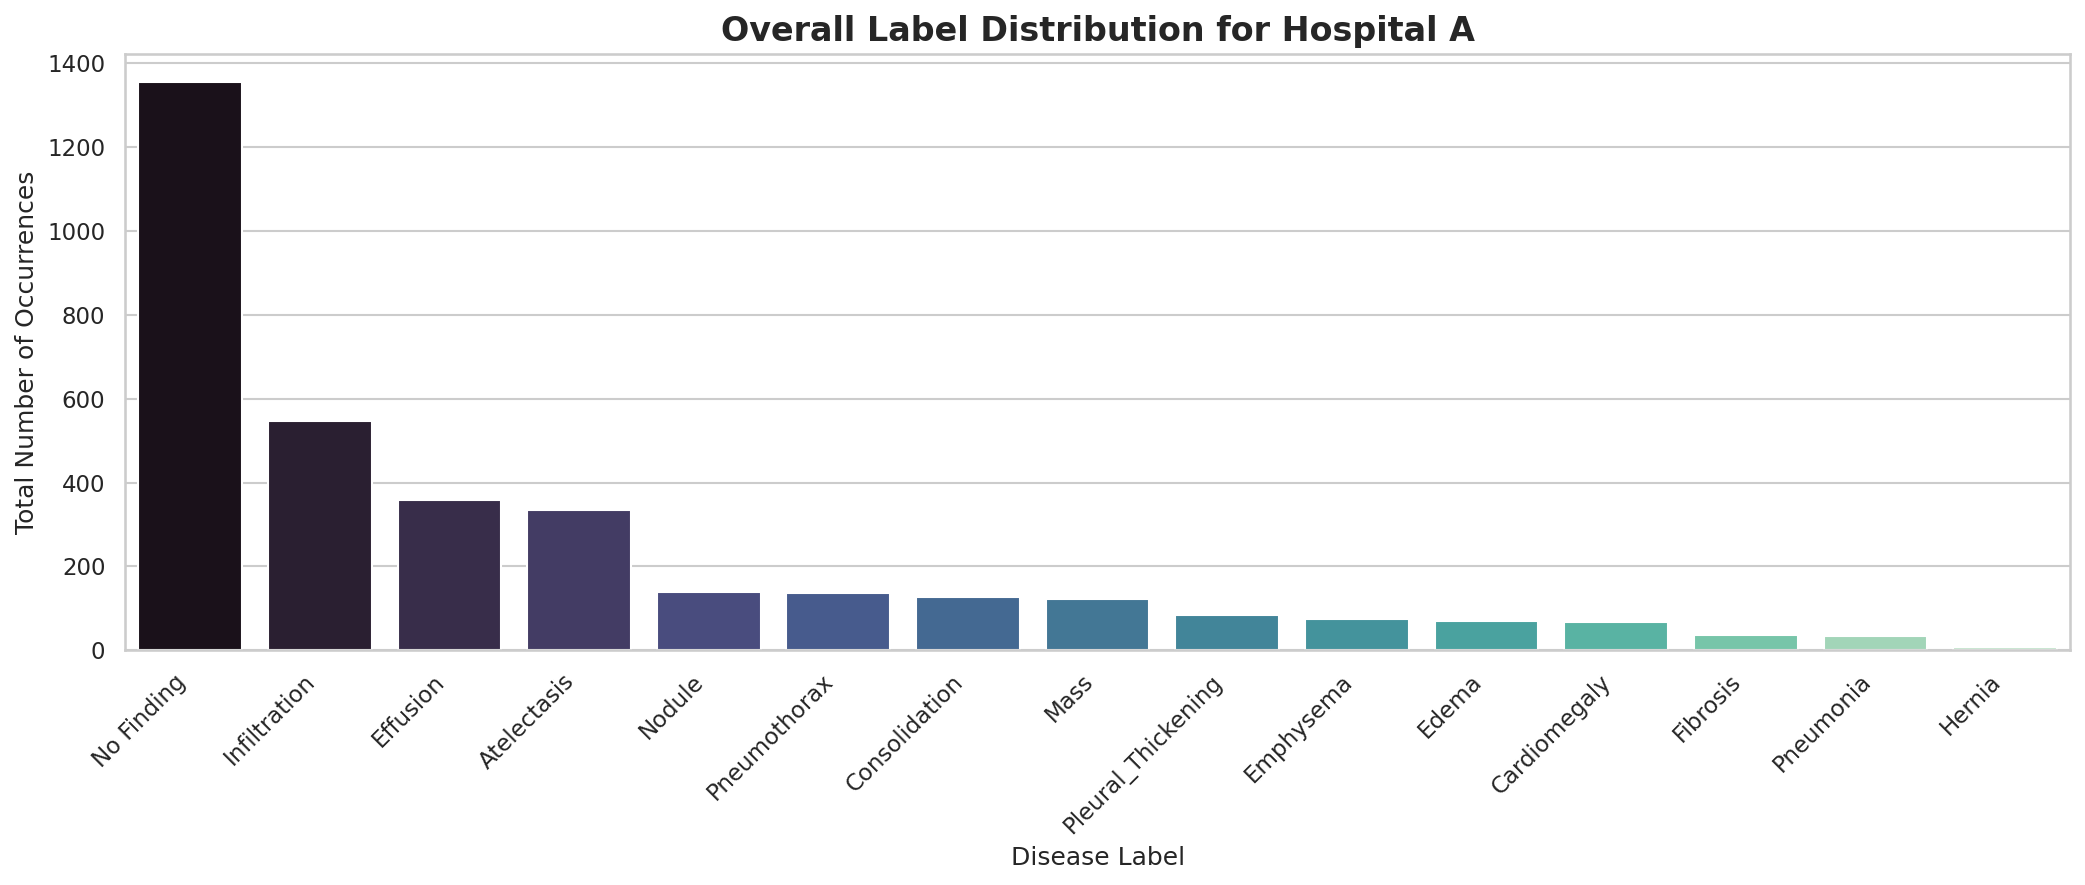

In [36]:
data_dir = "../../data/hospital_a/"

train_files_a = glob.glob(os.path.join(data_dir, 'train-*.parquet'))
eval_files_a = glob.glob(os.path.join(data_dir, 'eval-*.parquet'))

print("Loading into memory...")

df_train_a = pd.concat([pd.read_parquet(f) for f in train_files_a], ignore_index=True)
df_train_a['split'] = 'train'
df_eval_a = pd.concat([pd.read_parquet(f) for f in eval_files_a], ignore_index=True)
df_eval_a['split'] = 'eval'

print(f"Size of hospital A train set: {len(df_train_a)}")
print(f"Size of hospital A eval set: {len(df_eval_a)}")

df_combined_a = pd.concat([df_train_a, df_eval_a])

df_to_plot = df_combined_a.explode('label')

plt.figure(figsize=(14, 6))

label_order = df_to_plot['label'].value_counts().index

sns.countplot(
    data=df_to_plot, 
    x='label', 
    order=label_order, 
    palette='mako'
)

plt.title('Overall Label Distribution for Hospital A', fontsize=16, fontweight='bold')
plt.xlabel('Disease Label', fontsize=12)
plt.ylabel('Total Number of Occurrences', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.rcParams['figure.dpi'] = 300
plt.show()

# Hospital B

In [24]:
data_dir = "../../data/hospital_b/"

train_files_b = glob.glob(os.path.join(data_dir, 'train-*.parquet'))
eval_files_b = glob.glob(os.path.join(data_dir, 'eval-*.parquet'))

print("Loading into memory...")

df_train_b = pd.concat([pd.read_parquet(f) for f in train_files_b], ignore_index=True)
df_train_b['split'] = 'train'
df_eval_b = pd.concat([pd.read_parquet(f) for f in eval_files_b], ignore_index=True)
df_eval_b['split'] = 'eval'

print(f"Size of hospital B train set: {len(df_train_b)}")
print(f"Size of hospital B eval set: {len(df_eval_b)}")


Loading into memory...
Size of hospital B train set: 2322
Size of hospital B eval set: 306


# Hospital C

In [25]:
data_dir = "../../data/hospital_c/"

train_files_c = glob.glob(os.path.join(data_dir, 'train-*.parquet'))
eval_files_c = glob.glob(os.path.join(data_dir, 'eval-*.parquet'))

print("Loading into memory...")

df_train_c = pd.concat([pd.read_parquet(f) for f in train_files_c], ignore_index=True)
df_train_c['split'] = 'train'
df_eval_c = pd.concat([pd.read_parquet(f) for f in eval_files_c], ignore_index=True)
df_eval_c['split'] = 'eval'

print(f"Size of hospital C train set: {len(df_train_c)}")
print(f"Size of hospital C eval set: {len(df_eval_c)}")


Loading into memory...
Size of hospital C train set: 2363
Size of hospital C eval set: 312


In [26]:
print(df_train_a.columns)

Index(['image', 'label', 'Patient Age', 'Patient Gender', 'View Position',
       'Patient ID', 'split'],
      dtype='object')


# Combined Label Distribution

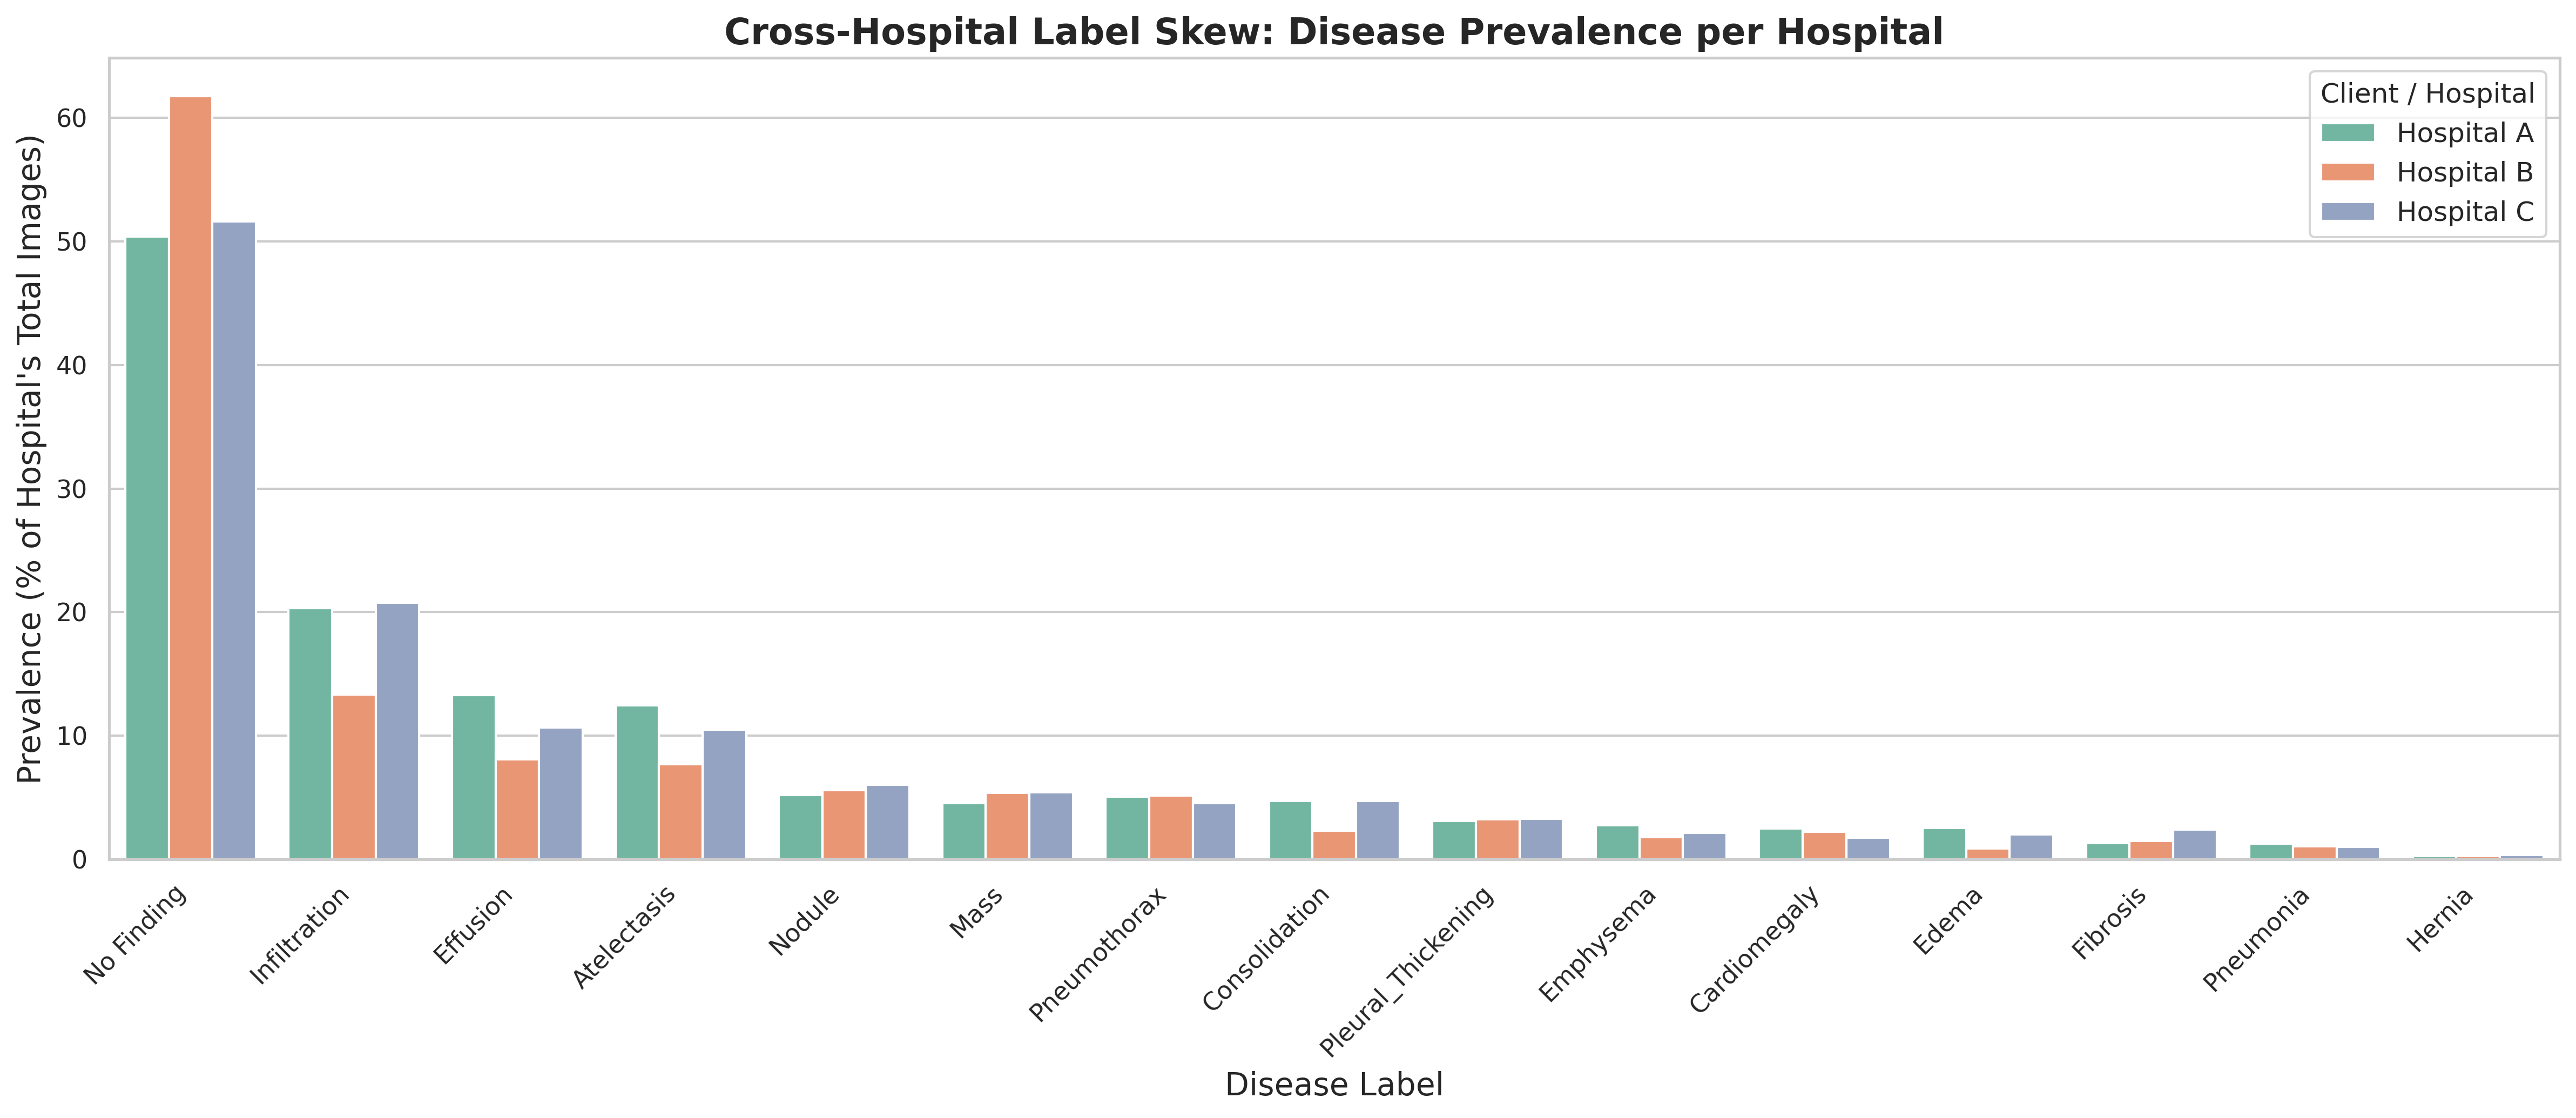

In [ ]:
df_combined_a = pd.concat([df_train_a, df_eval_a])
df_combined_b = pd.concat([df_train_b, df_eval_b])
df_combined_c = pd.concat([df_train_c, df_eval_c])

# Add column to know which data came from where
df_combined_a['hospital'] = 'Hospital A'
df_combined_b['hospital'] = 'Hospital B'
df_combined_c['hospital'] = 'Hospital C'

df_all = pd.concat([df_combined_a, df_combined_b, df_combined_c], ignore_index=True)

label_col = 'label'

hospital_totals = df_all.groupby('hospital').size()

df_exploded = df_all.explode(label_col)

label_counts = df_exploded.groupby(['hospital', label_col]).size().reset_index(name='count')

# Calculate the prevalence (percentage) of each disease per hospital
# Formula: (Number of times disease appears at Hospital X) / (Total images at Hospital X) * 100
label_counts['percentage'] = label_counts.apply(
    lambda row: (row['count'] / hospital_totals[row['hospital']]) * 100, axis=1
)

plt.figure(figsize=(16, 7))

order = df_exploded[label_col].value_counts().index # sort by frequency

sns.barplot(
    data=label_counts, 
    x=label_col, 
    y='percentage', 
    hue='hospital', 
    order=order,
    palette='Set2'
)

plt.title('Cross-Hospital Label Skew: Disease Prevalence per Hospital', fontsize=16, fontweight='bold')
plt.xlabel('Disease Label', fontsize=14)
plt.ylabel('Prevalence (% of Hospital\'s Total Images)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Client / Hospital', fontsize=12)
plt.tight_layout()
plt.show()

# Pearson Correlation Matrix for Diseases
Blue values: If a patient has one disease, they rarely have the other.  
Red values: The two diseases frequently appear together.

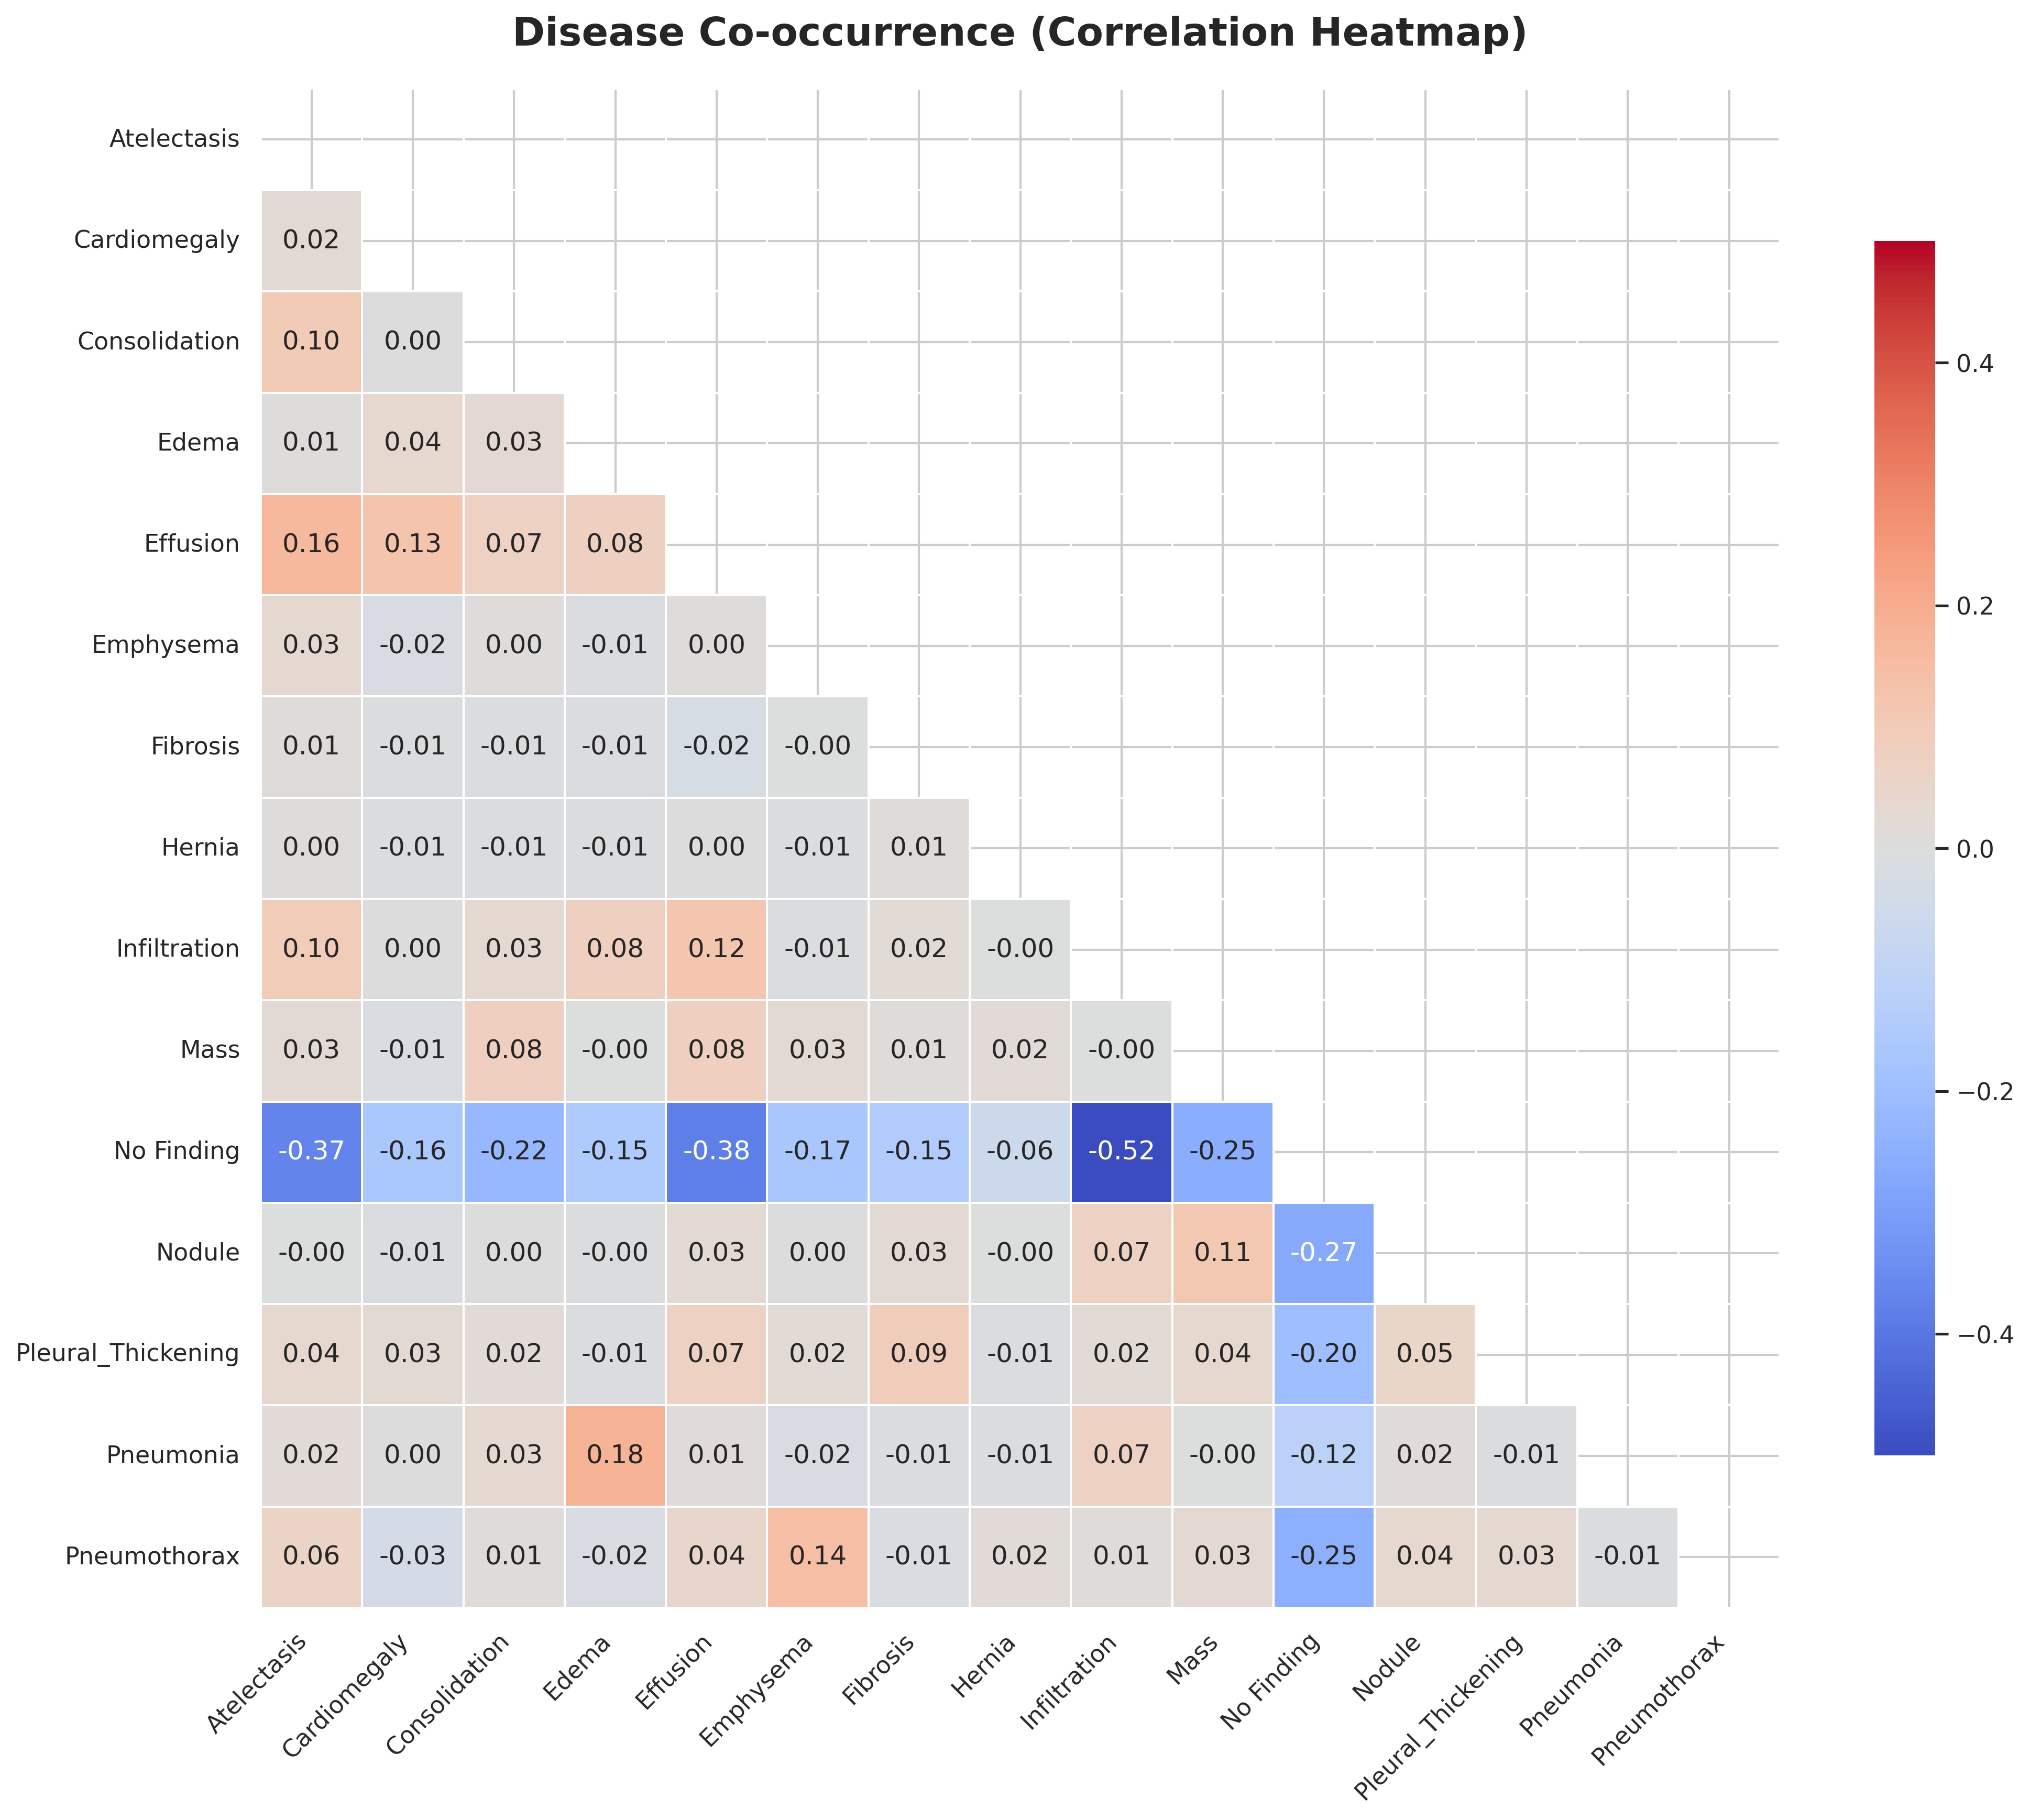

In [42]:
# Multi-Hot encode data
mlb = MultiLabelBinarizer()
binary_labels = mlb.fit_transform(df_all['label'].dropna()) 
df_binary = pd.DataFrame(binary_labels, columns=mlb.classes_)

# Calculate the Pearson correlation matrix
correlation_matrix = df_binary.corr()

# Create a mask to hide the upper triangle (readability step)
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))


plt.figure(figsize=(14, 12))

sns.heatmap(
    correlation_matrix, 
    mask=mask, 
    cmap='coolwarm', # Blue for negative correlation, Red for positive
    vmax=0.5,        
    vmin=-0.5,       
    center=0, 
    annot=True,      # Show numbers inside the boxes
    fmt=".2f",       
    square=True,     
    linewidths=.5, 
    cbar_kws={"shrink": .75}
)

plt.title('Disease Co-occurrence (Correlation Heatmap)', fontsize=18, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()